# 06 - Model Training and Evaluation

This notebook trains the first leakage-reviewed default prediction models for the Canadian retail credit risk project.

The goal is to compare a transparent baseline model against stronger ensemble candidates while keeping the modelling process auditable, reproducible, and aligned with credit-risk model governance expectations.

## Professional framing

This notebook uses the modelling dataset created in Notebook 05. All imputation, scaling, and one-hot encoding are fit inside scikit-learn pipelines using the training split only.

Model comparison focuses on credit-risk relevant metrics:

1. **PR-AUC** because defaults are the minority class.
2. **ROC-AUC** for general discriminatory power.
3. **Recall** because missed defaults can be costly.
4. **Precision and review rate** because too many false alerts can overload credit-review teams.
5. **Brier score** because calibrated probabilities matter for risk ranking and portfolio monitoring.
6. **MCC and balanced accuracy** because accuracy alone is misleading when the default rate is low.

Threshold optimization is deferred to Notebook 07. Here, models are evaluated at the default 0.50 threshold and ranked primarily by validation PR-AUC.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT / "src"))

from credit_risk.config import MODEL_ARTIFACT_DIR, PROCESSED_DIR, TABLE_DIR
from credit_risk.models.train import (
    infer_feature_columns,
    save_model_training_artifacts,
    train_and_evaluate_candidate_models,
)

MODELING_PATH = PROCESSED_DIR / "credit_risk_modeling_dataset.csv"
MODELING_PATH

WindowsPath('D:/Banking and Finance/Projects/canadian-retail-credit-risk-xai/data/processed/credit_risk_modeling_dataset.csv')

## Load leakage-reviewed modelling dataset

In [2]:
modeling_df = pd.read_csv(MODELING_PATH, low_memory=False)

load_summary = {
    "row_count": modeling_df.shape[0],
    "column_count": modeling_df.shape[1],
    "target_default_rate": float(modeling_df["defaulter"].mean()),
    "record_key_duplicate_count": int(modeling_df.duplicated(["user_id", "record_sequence"]).sum()),
    "split_values": sorted(modeling_df["split"].dropna().unique().tolist()),
}
load_summary

{'row_count': 134417,
 'column_count': 51,
 'target_default_rate': 0.0904126710163149,
 'record_key_duplicate_count': 0,
 'split_values': ['test', 'train', 'validation']}

The row count, target rate, and split labels should match Notebook 05. Stop before training if this check does not pass.

In [3]:
split_check = (
    modeling_df.groupby("split")
    .agg(
        row_count=("defaulter", "size"),
        default_count=("defaulter", "sum"),
        default_rate=("defaulter", "mean"),
    )
    .reset_index()
)
split_check["default_rate_pct"] = split_check["default_rate"] * 100
split_check

,split,row_count,default_count,default_rate,default_rate_pct
0,test,20163,1823,0.090413,9.041313
1,train,94091,8507,0.090412,9.041247
2,validation,20163,1823,0.090413,9.041313


## Feature set used for model training

In [4]:
numeric_features, categorical_features = infer_feature_columns(modeling_df)

feature_summary = {
    "numeric_features": len(numeric_features),
    "categorical_features": len(categorical_features),
    "total_features": len(numeric_features) + len(categorical_features),
}
feature_summary

{'numeric_features': 35, 'categorical_features': 12, 'total_features': 47}

In [5]:
feature_catalog = pd.DataFrame(
    {
        "feature": numeric_features + categorical_features,
        "feature_type": ["numeric"] * len(numeric_features) + ["categorical"] * len(categorical_features),
    }
)
feature_catalog.head(20)

,feature,feature_type
0,amount,numeric
1,interest_rate,numeric
2,tenure_years,numeric
3,total_income_pa,numeric
4,dependents,numeric
5,delinq_2yrs,numeric
6,number_of_loans,numeric
7,loan_to_income_ratio,numeric
8,amount_missing_flag,numeric
9,employment_type_missing_flag,numeric


## Train candidate models

Candidate models:

1. **Class-weighted Logistic Regression** as the interpretable benchmark.
2. **Class-weighted Random Forest** as a nonlinear ensemble challenger.
3. **Weighted XGBoost** as the primary gradient-boosting challenger.

The models are fitted only on the training split. Validation and test splits are not used to fit preprocessing steps.

In [6]:
artifacts = train_and_evaluate_candidate_models(modeling_df, random_state=42)

print(f"Trained models: {list(artifacts.fitted_models.keys())}")
print(f"Champion by validation ranking: {artifacts.champion_model_name}")

Trained models: ['logistic_regression_balanced', 'random_forest_balanced', 'xgboost_weighted']
Champion by validation ranking: xgboost_weighted


## Validation performance at default 0.50 threshold

Validation results are used for model selection. PR-AUC is prioritized because default is a minority class and the business cares about ranking risky borrowers for review.

In [7]:
validation_results = artifacts.validation_results.copy()
validation_results

,model_name,dataset,threshold,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1,mcc,review_rate,business_cost,true_negative,false_positive,false_negative,true_positive,default_count,non_default_count
0,xgboost_weighted,validation,0.5,0.751101,0.229393,0.204092,0.659773,0.687249,0.171429,0.720790,0.276981,0.221241,0.380152,5720500.0,11989,6351,509,1314,1823,18340
1,random_forest_balanced,validation,0.5,0.743713,0.223398,0.198218,0.677032,0.680681,0.173786,0.685134,0.277248,0.216367,0.356445,5839000.0,12402,5938,574,1249,1823,18340
2,logistic_regression_balanced,validation,0.5,0.744390,0.219675,0.208386,0.671825,0.676583,0.170832,0.682392,0.273256,0.210849,0.361157,5914000.0,12302,6038,579,1244,1823,18340


In [8]:
artifacts.selection_summary

,selection_rank,model_name,dataset,pr_auc,roc_auc,brier_score,recall,precision,f1,balanced_accuracy,mcc,review_rate,business_cost,false_negative,false_positive,true_positive,true_negative
0,1,xgboost_weighted,validation,0.229393,0.751101,0.204092,0.720790,0.171429,0.276981,0.687249,0.221241,0.380152,5720500.0,509,6351,1314,11989
1,2,random_forest_balanced,validation,0.223398,0.743713,0.198218,0.685134,0.173786,0.277248,0.680681,0.216367,0.356445,5839000.0,574,5938,1249,12402
2,3,logistic_regression_balanced,validation,0.219675,0.744390,0.208386,0.682392,0.170832,0.273256,0.676583,0.210849,0.361157,5914000.0,579,6038,1244,12302


## Test-set performance

The test split is kept as a final holdout view. The selected champion should not be changed based on the test table unless there is evidence of severe instability.

In [9]:
test_results = artifacts.test_results.copy()
test_results

,model_name,dataset,threshold,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1,mcc,review_rate,business_cost,true_negative,false_positive,false_negative,true_positive,default_count,non_default_count
0,xgboost_weighted,test,0.5,0.746768,0.216785,0.203494,0.660765,0.690758,0.172904,0.727372,0.279393,0.225365,0.380350,5656500.0,11997,6343,497,1326,1823,18340
1,random_forest_balanced,test,0.5,0.741073,0.211881,0.197055,0.676784,0.679309,0.173211,0.682392,0.276291,0.214758,0.356197,5864000.0,12402,5938,579,1244,1823,18340
2,logistic_regression_balanced,test,0.5,0.739519,0.209193,0.208108,0.674900,0.683460,0.174194,0.693911,0.278481,0.219193,0.360165,5788500.0,12343,5997,558,1265,1823,18340


## Compare ranking metrics

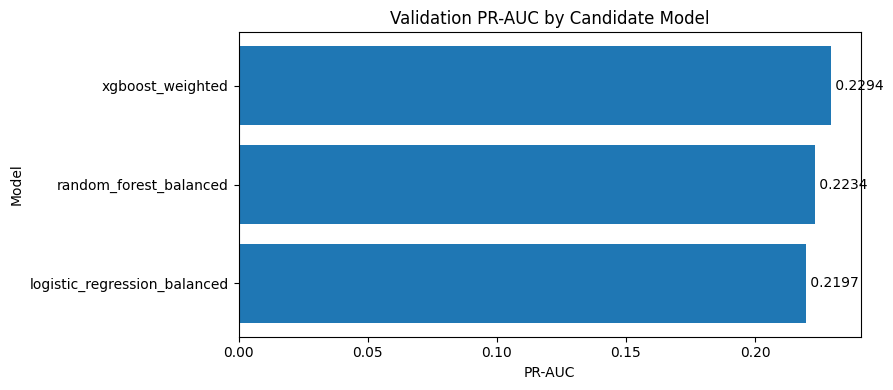

In [10]:
plot_df = validation_results.sort_values("pr_auc", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(plot_df["model_name"], plot_df["pr_auc"])
ax.set_title("Validation PR-AUC by Candidate Model")
ax.set_xlabel("PR-AUC")
ax.set_ylabel("Model")
for idx, value in enumerate(plot_df["pr_auc"]):
    ax.text(value, idx, f" {value:.4f}", va="center")
plt.tight_layout()
plt.show()

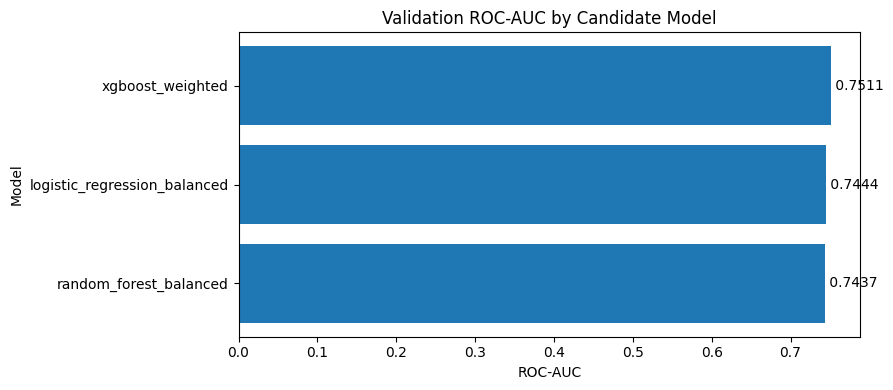

In [11]:
plot_df = validation_results.sort_values("roc_auc", ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(plot_df["model_name"], plot_df["roc_auc"])
ax.set_title("Validation ROC-AUC by Candidate Model")
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("Model")
for idx, value in enumerate(plot_df["roc_auc"]):
    ax.text(value, idx, f" {value:.4f}", va="center")
plt.tight_layout()
plt.show()

## Confusion-matrix review at 0.50 threshold

This table translates model performance into operational risk. A model with strong ranking metrics can still need threshold tuning if the default 0.50 cutoff produces too few or too many review cases.

In [12]:
confusion_cols = [
    "model_name",
    "dataset",
    "threshold",
    "true_positive",
    "false_positive",
    "false_negative",
    "true_negative",
    "recall",
    "precision",
    "review_rate",
    "business_cost",
]
validation_results[confusion_cols]

,model_name,dataset,threshold,true_positive,false_positive,false_negative,true_negative,recall,precision,review_rate,business_cost
0,xgboost_weighted,validation,0.5,1314,6351,509,11989,0.720790,0.171429,0.380152,5720500.0
1,random_forest_balanced,validation,0.5,1249,5938,574,12402,0.685134,0.173786,0.356445,5839000.0
2,logistic_regression_balanced,validation,0.5,1244,6038,579,12302,0.682392,0.170832,0.361157,5914000.0


## Save model artifacts and experiment tables

The saved outputs support later threshold selection, explainability, and governance documentation.

In [13]:
save_model_training_artifacts(artifacts, TABLE_DIR, MODEL_ARTIFACT_DIR)

saved_outputs = {
    "validation_results": str(TABLE_DIR / "model_validation_results_default_threshold.csv"),
    "test_results": str(TABLE_DIR / "model_test_results_default_threshold.csv"),
    "selection_summary": str(TABLE_DIR / "model_selection_summary.csv"),
    "validation_predictions": str(TABLE_DIR / "validation_predictions_default_threshold.csv"),
    "test_predictions": str(TABLE_DIR / "test_predictions_default_threshold.csv"),
    "candidate_models": str(MODEL_ARTIFACT_DIR / "candidate_models.joblib"),
    "champion_model": str(MODEL_ARTIFACT_DIR / "champion_model.joblib"),
    "feature_metadata": str(MODEL_ARTIFACT_DIR / "model_feature_metadata.joblib"),
}
saved_outputs

{'validation_results': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\model_validation_results_default_threshold.csv',
 'test_results': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\model_test_results_default_threshold.csv',
 'selection_summary': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\model_selection_summary.csv',
 'validation_predictions': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\validation_predictions_default_threshold.csv',
 'test_predictions': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\tables\\test_predictions_default_threshold.csv',
 'candidate_models': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\model_artifacts\\candidate_models.joblib',
 'champion_model': 'D:\\Banking and Finance\\Projects\\canadian-retail-credit-risk-xai\\reports\\model_artif

## Key Findings

| Model | Validation PR-AUC | Validation ROC-AUC | Recall | Precision | Review Rate |
|---|---:|---:|---:|---:|---:|
| XGBoost weighted | 0.2294 | 0.7511 | 72.08% | 17.14% | 38.02% |
| Random Forest balanced | 0.2234 | 0.7437 | 68.51% | 17.38% | 35.64% |
| Logistic Regression balanced | 0.2197 | 0.7444 | 68.24% | 17.08% | 36.12% |

## Notebook 06 conclusions

Carry these decisions forward into Notebook 07:

1. The champion model is selected using validation PR-AUC, with ROC-AUC, calibration, MCC, recall, precision, and review rate as supporting evidence.
2. The default 0.50 threshold is not expected to be the final business threshold for a credit-risk review strategy.
3. Notebook 07 should choose a business threshold using recall, precision, review-capacity, and estimated cost trade-offs.
4. Notebook 08 should explain the selected champion model using SHAP, local explanations, and business-friendly reason codes.
5. Notebook 09 should convert model results into governance artifacts: model card, validation summary, limitations, monitoring plan, and stakeholder brief.